# Reusable Quantum Kernel Estimators

Use the dataset-agnostic `QuantumKernel`, `QuantumKernelClassifier`, and `QuantumKernelRegressor` APIs on two compact supervised tasks. The notebook keeps classical kernel baselines for calibration and prints a validation block in the same style as the real-example notebooks.

## Tutorial Goals

This tutorial uses the reusable quantum kernel estimator classes directly. You will:

- build `QuantumKernel` matrices from user-supplied arrays
- train `QuantumKernelClassifier` and `QuantumKernelRegressor`
- compute kernel-target alignment
- compare against classical kernel baselines

This is the right starting point when your data already exists outside the package dataset generators.

## Problem, Variables, and Quantum Advantage Context

**Learning problem.** The classifier separates two noisy sensor states from two measured features. The regressor learns a smooth calibration curve from engineered two-feature inputs.

**Explicit variables.** `x_class` and `y_class` are the classification features and labels. `kernel_matrix_train` is the PennyLane fidelity-kernel matrix used by the SVM. `alignment` is normalized kernel-target alignment. `x_reg` and `y_reg` are the regression features and targets. `q_class_pred` and `q_reg_pred` are held-out predictions from the quantum-kernel estimators.

**Quantum advantage context.** Quantum kernels provide feature maps through quantum state overlaps. This notebook does **not** prove quantum advantage; it validates the reusable kernel-estimator API against small classical baselines.

In [1]:
from pathlib import Path
import sys
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig")

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
elif not (repo_root / "src" / "qml").exists():
    repo_root = next((parent for parent in repo_root.parents if (parent / "src" / "qml").exists()), repo_root)

package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

import numpy as np
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import matplotlib.pyplot as plt

from qml import (
    QuantumKernel,
    QuantumKernelClassifier,
    QuantumKernelRegressor,
    kernel_target_alignment,
)
from qml.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from qml.reporting import print_section


## Domain simulator

The first task mimics two separable operating regimes in a two-sensor measurement plane. The second task is a one-dimensional calibration curve represented with two nonlinear features.

In [2]:
rng = np.random.default_rng(31)

n_per_class = 10
state_low = rng.normal(loc=[-0.75, -0.55], scale=0.12, size=(n_per_class, 2))
state_high = rng.normal(loc=[0.75, 0.55], scale=0.12, size=(n_per_class, 2))
x_class = np.vstack([state_low, state_high])
y_class = np.asarray([0] * n_per_class + [1] * n_per_class)

x_class_train, x_class_test, y_class_train, y_class_test = train_test_split(
    x_class, y_class, test_size=0.3, random_state=31, stratify=y_class
)
class_scaler = StandardScaler()
x_class_train = class_scaler.fit_transform(x_class_train)
x_class_test = class_scaler.transform(x_class_test)

calibration_axis = np.linspace(-1.0, 1.0, 20)
x_reg = np.column_stack([calibration_axis, np.cos(np.pi * calibration_axis)])
y_reg = 0.65 * np.sin(np.pi * calibration_axis) + 0.25 * np.cos(2.0 * np.pi * calibration_axis)

x_reg_train, x_reg_test, y_reg_train, y_reg_test = train_test_split(
    x_reg, y_reg, test_size=0.3, random_state=32
)
reg_scaler = StandardScaler()
x_reg_train = reg_scaler.fit_transform(x_reg_train)
x_reg_test = reg_scaler.transform(x_reg_test)

print_section(
    "Dataset",
    [
        ("Classification samples", int(len(y_class))),
        ("Classification feature_shape", list(x_class.shape)),
        ("Regression samples", int(len(y_reg))),
        ("Regression feature_shape", list(x_reg.shape)),
        ("Regression target range", [float(y_reg.min()), float(y_reg.max())]),
    ],
)

Dataset
+------------------------------+---------------------+
| Metric                       | Value               |
+------------------------------+---------------------+
| Classification samples       | 20                  |
| Classification feature_shape | [20, 2]             |
| Regression samples           | 20                  |
| Regression feature_shape     | [20, 2]             |
| Regression target range      | [-0.89437, 0.46061] |
+------------------------------+---------------------+



## Package-client quantum kernel models

In [3]:
classification_kernel = QuantumKernel(seed=31)
kernel_matrix_train = classification_kernel.evaluate(x_class_train)
alignment = kernel_target_alignment(kernel_matrix_train, y_class_train)

q_classifier = QuantumKernelClassifier(classification_kernel, c=1.0)
q_classifier.fit(x_class_train, y_class_train)
q_class_pred = q_classifier.predict(x_class_test)

svc_baseline = SVC(kernel="rbf", gamma="scale")
svc_baseline.fit(x_class_train, y_class_train)
svc_class_pred = svc_baseline.predict(x_class_test)

regression_kernel = QuantumKernel(seed=32)
q_regressor = QuantumKernelRegressor(regression_kernel, alpha=1e-3)
q_regressor.fit(x_reg_train, y_reg_train)
q_reg_pred = q_regressor.predict(x_reg_test)

krr_baseline = KernelRidge(alpha=1e-3, kernel="rbf")
krr_baseline.fit(x_reg_train, y_reg_train)
krr_reg_pred = krr_baseline.predict(x_reg_test)

results = {
    "kernel_target_alignment": float(alignment),
    "quantum_classifier_accuracy": accuracy_score(y_class_test, q_class_pred),
    "svc_classifier_accuracy": accuracy_score(y_class_test, svc_class_pred),
    "quantum_regression_mae": mean_absolute_error(y_reg_test, q_reg_pred),
    "quantum_regression_mse": mean_squared_error(y_reg_test, q_reg_pred),
    "krr_regression_mae": mean_absolute_error(y_reg_test, krr_reg_pred),
}

print_section(
    "Results",
    [
        ("Kernel-target alignment", results["kernel_target_alignment"]),
        ("Quantum classifier accuracy", results["quantum_classifier_accuracy"]),
        ("SVC classifier accuracy", results["svc_classifier_accuracy"]),
        ("Quantum regression MAE", results["quantum_regression_mae"]),
        ("Quantum regression MSE", results["quantum_regression_mse"]),
        ("Kernel ridge regression MAE", results["krr_regression_mae"]),
    ],
)

Results
+-----------------------------+-----------+
| Metric                      | Value     |
+-----------------------------+-----------+
| Kernel-target alignment     | 0.634204  |
| Quantum classifier accuracy | 1         |
| SVC classifier accuracy     | 1         |
| Quantum regression MAE      | 0.0861475 |
| Quantum regression MSE      | 0.0186331 |
| Kernel ridge regression MAE | 0.0208563 |
+-----------------------------+-----------+



## Plots

The plots show the classification data, the quantum kernel matrix, and held-out regression predictions.

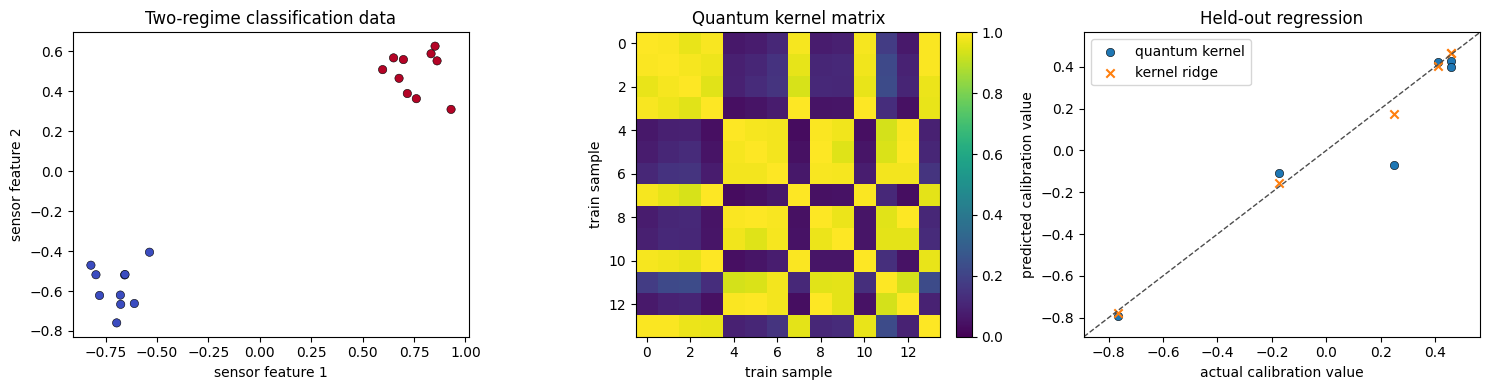

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(
    x_class[:, 0], x_class[:, 1], c=y_class, cmap="coolwarm", edgecolor="black", linewidth=0.4
)
axes[0].set_title("Two-regime classification data")
axes[0].set_xlabel("sensor feature 1")
axes[0].set_ylabel("sensor feature 2")

image = axes[1].imshow(kernel_matrix_train, cmap="viridis", vmin=0.0, vmax=1.0)
axes[1].set_title("Quantum kernel matrix")
axes[1].set_xlabel("train sample")
axes[1].set_ylabel("train sample")
fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)

order = np.argsort(y_reg_test)
axes[2].scatter(y_reg_test, q_reg_pred, label="quantum kernel", edgecolor="black", linewidth=0.4)
axes[2].scatter(y_reg_test, krr_reg_pred, label="kernel ridge", marker="x")
low = min(y_reg_test.min(), q_reg_pred.min(), krr_reg_pred.min()) - 0.1
high = max(y_reg_test.max(), q_reg_pred.max(), krr_reg_pred.max()) + 0.1
axes[2].plot([low, high], [low, high], color="0.3", linestyle="--", linewidth=1)
axes[2].set_xlim(low, high)
axes[2].set_ylim(low, high)
axes[2].set_title("Held-out regression")
axes[2].set_xlabel("actual calibration value")
axes[2].set_ylabel("predicted calibration value")
axes[2].legend()

fig.tight_layout()
plt.show()

## Validation block

This final cell checks that the kernel estimators produce finite predictions, a useful alignment value, and non-trivial held-out performance.

In [5]:
validation = {
    "dataset": {
        "problem": "reusable_quantum_kernel_estimators",
        "classification_features": ["sensor_feature_1", "sensor_feature_2"],
        "classification_target": "operating_regime",
        "regression_features": ["calibration_axis", "cosine_feature"],
        "regression_target": "calibration_value",
        "n_class_train": int(len(y_class_train)),
        "n_class_test": int(len(y_class_test)),
        "n_reg_train": int(len(y_reg_train)),
        "n_reg_test": int(len(y_reg_test)),
    },
    "results": results,
    "sample_class_predictions": [
        {"actual": int(a), "quantum": int(q), "svc": int(s)}
        for a, q, s in zip(y_class_test[:6], q_class_pred[:6], svc_class_pred[:6])
    ],
    "sample_regression_predictions": [
        {"actual": float(a), "quantum": float(q), "kernel_ridge": float(k)}
        for a, q, k in zip(y_reg_test[:6], q_reg_pred[:6], krr_reg_pred[:6])
    ],
    "passed": bool(
        np.isfinite(kernel_matrix_train).all()
        and np.isfinite(q_reg_pred).all()
        and results["kernel_target_alignment"] > 0.2
        and results["quantum_classifier_accuracy"] >= 0.8
        and results["quantum_regression_mae"] < 0.25
    ),
}

print("Validation")
print_section(
    "Dataset",
    [
        ("Problem", validation["dataset"]["problem"]),
        ("Classification features", validation["dataset"]["classification_features"]),
        ("Classification target", validation["dataset"]["classification_target"]),
        ("Regression features", validation["dataset"]["regression_features"]),
        ("Regression target", validation["dataset"]["regression_target"]),
        ("Classification train samples", validation["dataset"]["n_class_train"]),
        ("Classification test samples", validation["dataset"]["n_class_test"]),
        ("Regression train samples", validation["dataset"]["n_reg_train"]),
        ("Regression test samples", validation["dataset"]["n_reg_test"]),
    ],
)
print_section(
    "Results",
    [
        ("Kernel-target alignment", validation["results"]["kernel_target_alignment"]),
        ("Quantum classifier accuracy", validation["results"]["quantum_classifier_accuracy"]),
        ("SVC classifier accuracy", validation["results"]["svc_classifier_accuracy"]),
        ("Quantum regression MAE", validation["results"]["quantum_regression_mae"]),
        ("Quantum regression MSE", validation["results"]["quantum_regression_mse"]),
        ("Kernel ridge regression MAE", validation["results"]["krr_regression_mae"]),
    ],
)
print("Sample classification predictions")
for index, row in enumerate(validation["sample_class_predictions"], start=1):
    print(f"{index}. Actual: {row['actual']}, Quantum: {row['quantum']}, SVC: {row['svc']}")
print()
print("Sample regression predictions")
for index, row in enumerate(validation["sample_regression_predictions"], start=1):
    print(
        f"{index}. Actual: {row['actual']:.6f}, "
        f"Quantum: {row['quantum']:.6f}, "
        f"Kernel ridge: {row['kernel_ridge']:.6f}"
    )
print()
print("Interpretation")
print("The reusable quantum kernel estimators produced finite predictions and useful held-out metrics.")
print("Classical baselines are included as sanity checks; no quantum advantage is claimed.")
print()
print(f"Passed: {validation['passed']}")
assert validation["passed"]

Validation
Dataset
+------------------------------+--------------------------------------+
| Metric                       | Value                                |
+------------------------------+--------------------------------------+
| Problem                      | reusable_quantum_kernel_estimators   |
| Classification features      | [sensor_feature_1, sensor_feature_2] |
| Classification target        | operating_regime                     |
| Regression features          | [calibration_axis, cosine_feature]   |
| Regression target            | calibration_value                    |
| Classification train samples | 14                                   |
| Classification test samples  | 6                                    |
| Regression train samples     | 14                                   |
| Regression test samples      | 6                                    |
+------------------------------+--------------------------------------+

Results
+-----------------------------+-----